In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("laptop_data.csv")

In [3]:
data.head(10)

,brand,cpu_brand,ram_gb,storage_gb,storage_type,gpu_brand,dedicated_gpu_vram_gb,screen_size_inch,screen_type,resolution,...,release_year,os,region,user_rating,num_reviews,touchscreen,backlit_keyboard,fingerprint_reader,wifi6_supported,price_inr
0,LG,AMD,24.0,512.0,SSD,Intel,4,17.5,IPS,2560x1440,...,2021,Ubuntu,Europe,3.7,324.0,1,1,0,1,74001
1,LG,AMD,32.0,512.0,HDD,Intel,8,15.4,VA,3840x2160,...,2016,macOS,SE Asia,1.5,2260.0,0,1,0,0,78994
2,MSI,Intel,32.0,2048.0,NaN,AMD,6,13.9,TN,1920x1080,...,2022,Windows 11,SE Asia,2.8,4942.0,0,1,1,0,99716
3,Lenovo,AMD,24.0,512.0,HDD,NVIDIA,2,13.3,TN,1366x768,...,2021,Windows 11,Middle East,2.8,2469.0,1,0,0,1,70380
4,LG,Intel,16.0,512.0,Hybrid,Intel,4,14.4,OLED,3840x2160,...,2015,Windows 11,Middle East,4.1,1367.0,0,1,1,0,53944
5,Samsung,Apple Silicon,8.0,256.0,SSD,Intel,12,17.6,IPS,2560x1440,...,2022,Windows 11,Middle East,1.7,1835.0,1,1,1,0,72991
6,Lenovo,AMD,12.0,256.0,HDD,NVIDIA,4,11.4,VA,2560x1440,...,2024,macOS,USA,2.2,NaN,0,1,0,1,60948
7,HP,AMD,4.0,512.0,SSD,Intel,12,15.3,VA,1366x768,...,2022,Fedora,Middle East,3.5,2117.0,1,0,0,1,85867
8,Apple,Intel,12.0,NaN,NaN,Intel,6,14.0,VA,1920x1080,...,2019,macOS,Middle East,3.1,1331.0,1,1,0,0,60373
9,Acer,AMD,12.0,512.0,Hybrid,Intel,8,16.2,VA,1366x768,...,2018,Ubuntu,Europe,4.0,3654.0,0,1,1,1,75871


In [4]:
data.isnull().sum()

brand                       0
cpu_brand                   0
ram_gb                   4948
storage_gb               5009
storage_type             5060
gpu_brand                4999
dedicated_gpu_vram_gb       0
screen_size_inch            0
screen_type                 0
resolution                  0
weight_kg                5136
battery_wh                  0
release_year                0
os                          0
region                      0
user_rating              4976
num_reviews              4858
touchscreen                 0
backlit_keyboard            0
fingerprint_reader          0
wifi6_supported             0
price_inr                   0
dtype: int64

In [5]:
data.shape

(100000, 22)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   brand                  100000 non-null  object 
 1   cpu_brand              100000 non-null  object 
 2   ram_gb                 95052 non-null   float64
 3   storage_gb             94991 non-null   float64
 4   storage_type           94940 non-null   object 
 5   gpu_brand              95001 non-null   object 
 6   dedicated_gpu_vram_gb  100000 non-null  int64  
 7   screen_size_inch       100000 non-null  float64
 8   screen_type            100000 non-null  object 
 9   resolution             100000 non-null  object 
 10  weight_kg              94864 non-null   float64
 11  battery_wh             100000 non-null  int64  
 12  release_year           100000 non-null  int64  
 13  os                     100000 non-null  object 
 14  region                 100000 non-nul

In [7]:
data.columns

Index(['brand', 'cpu_brand', 'ram_gb', 'storage_gb', 'storage_type',
       'gpu_brand', 'dedicated_gpu_vram_gb', 'screen_size_inch', 'screen_type',
       'resolution', 'weight_kg', 'battery_wh', 'release_year', 'os', 'region',
       'user_rating', 'num_reviews', 'touchscreen', 'backlit_keyboard',
       'fingerprint_reader', 'wifi6_supported', 'price_inr'],
      dtype='object')

In [8]:
columns=data.columns.tolist()

In [9]:
columns

['brand',
 'cpu_brand',
 'ram_gb',
 'storage_gb',
 'storage_type',
 'gpu_brand',
 'dedicated_gpu_vram_gb',
 'screen_size_inch',
 'screen_type',
 'resolution',
 'weight_kg',
 'battery_wh',
 'release_year',
 'os',
 'region',
 'user_rating',
 'num_reviews',
 'touchscreen',
 'backlit_keyboard',
 'fingerprint_reader',
 'wifi6_supported',
 'price_inr']

In [10]:
data.describe()

,ram_gb,storage_gb,dedicated_gpu_vram_gb,screen_size_inch,weight_kg,battery_wh,release_year,user_rating,num_reviews,touchscreen,backlit_keyboard,fingerprint_reader,wifi6_supported,price_inr
count,95052.000000,94991.000000,100000.000000,100000.000000,94864.000000,100000.000000,100000.000000,95024.000000,95142.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,22.944536,959.339053,5.334460,14.496719,2.251946,63.239970,2019.486750,3.003409,2496.521662,0.499260,0.500080,0.501330,0.499650,77059.745710
std,18.992968,685.481720,3.944714,2.026638,0.721651,21.393726,2.873069,1.155044,1447.480520,0.500002,0.500002,0.500001,0.500002,23111.279457
min,4.000000,256.000000,0.000000,11.000000,1.000000,35.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27307.000000
25%,8.000000,512.000000,2.000000,12.700000,1.630000,45.000000,2017.000000,2.000000,1241.000000,0.000000,0.000000,0.000000,0.000000,60498.000000
50%,16.000000,1024.000000,4.000000,14.500000,2.260000,65.000000,2019.000000,3.000000,2494.000000,0.000000,1.000000,1.000000,0.000000,73304.500000
75%,32.000000,1024.000000,8.000000,16.300000,2.880000,80.000000,2022.000000,4.000000,3754.000000,1.000000,1.000000,1.000000,1.000000,89682.000000
max,64.000000,2048.000000,12.000000,18.000000,3.500000,99.000000,2024.000000,5.000000,4999.000000,1.000000,1.000000,1.000000,1.000000,154237.000000


In [11]:
data["ram_gb"].fillna(data["ram_gb"].mean(),inplace=True)
data["storage_gb"].fillna(data["storage_gb"].mean(),inplace=True)
data["storage_type"]=data["storage_type"].fillna(data["storage_type"].mode()[0])
data["gpu_brand"]=data["gpu_brand"].fillna(data["gpu_brand"].mode()[0])
data["weight_kg"].fillna(data["weight_kg"].mean(),inplace=True)
data["user_rating"].fillna(data["user_rating"].mean(),inplace=True)
data["num_reviews"].fillna(data["num_reviews"].mean(),inplace=True)

In [12]:
data.isnull().sum()

brand                    0
cpu_brand                0
ram_gb                   0
storage_gb               0
storage_type             0
gpu_brand                0
dedicated_gpu_vram_gb    0
screen_size_inch         0
screen_type              0
resolution               0
weight_kg                0
battery_wh               0
release_year             0
os                       0
region                   0
user_rating              0
num_reviews              0
touchscreen              0
backlit_keyboard         0
fingerprint_reader       0
wifi6_supported          0
price_inr                0
dtype: int64

In [13]:
data.describe()

,ram_gb,storage_gb,dedicated_gpu_vram_gb,screen_size_inch,weight_kg,battery_wh,release_year,user_rating,num_reviews,touchscreen,backlit_keyboard,fingerprint_reader,wifi6_supported,price_inr
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,22.944536,959.339053,5.334460,14.496719,2.251946,63.239970,2019.486750,3.003409,2496.521662,0.499260,0.500080,0.501330,0.499650,77059.745710
std,18.517116,668.093111,3.944714,2.026638,0.702875,21.393726,2.873069,1.125940,1411.883150,0.500002,0.500002,0.500001,0.500002,23111.279457
min,4.000000,256.000000,0.000000,11.000000,1.000000,35.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27307.000000
25%,8.000000,512.000000,2.000000,12.700000,1.660000,45.000000,2017.000000,2.100000,1302.000000,0.000000,0.000000,0.000000,0.000000,60498.000000
50%,16.000000,959.339053,4.000000,14.500000,2.251946,65.000000,2019.000000,3.003409,2496.521662,0.000000,1.000000,1.000000,0.000000,73304.500000
75%,32.000000,1024.000000,8.000000,16.300000,2.840000,80.000000,2022.000000,4.000000,3686.000000,1.000000,1.000000,1.000000,1.000000,89682.000000
max,64.000000,2048.000000,12.000000,18.000000,3.500000,99.000000,2024.000000,5.000000,4999.000000,1.000000,1.000000,1.000000,1.000000,154237.000000


In [14]:
outliers=["brand","cpu_brand","ram_gb","storage_gb",
          "storage_type","gpu_brand","dedicated_gpu_vram_gb",
          "screen_size_inch","screen_type"
]

In [15]:
outliers

['brand',
 'cpu_brand',
 'ram_gb',
 'storage_gb',
 'storage_type',
 'gpu_brand',
 'dedicated_gpu_vram_gb',
 'screen_size_inch',
 'screen_type']

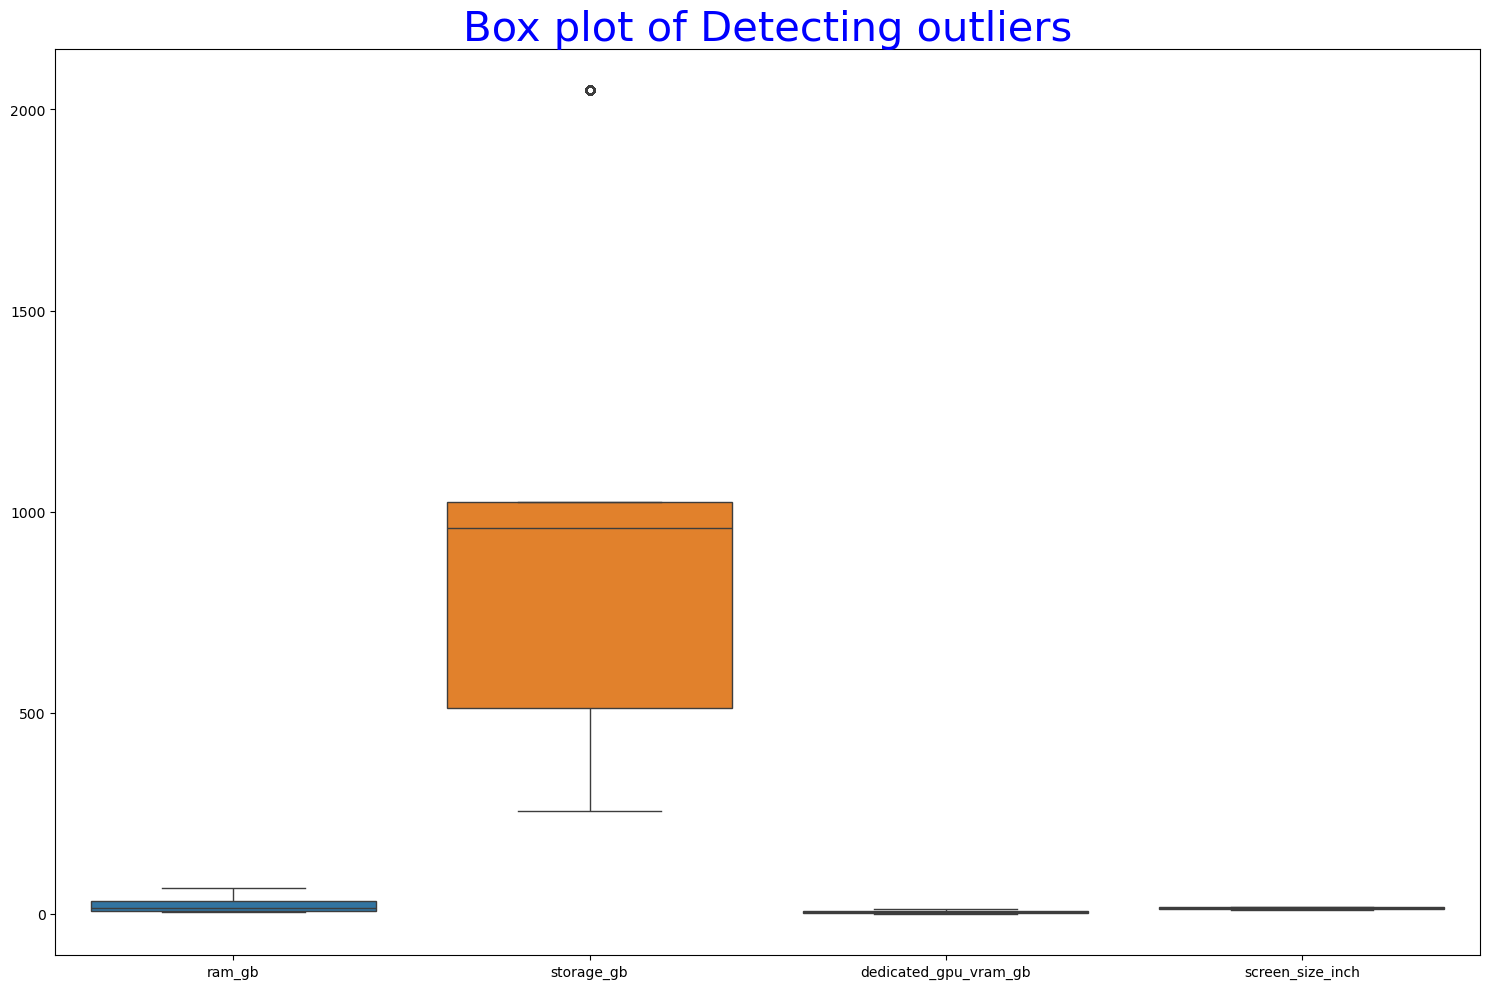

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(data=data[outliers])
plt.title("Box plot of Detecting outliers",color="blue",size=30)
plt.tight_layout()
plt.show()

In [17]:
outlier_1=["resolution","weight_kg","battery_wh","release_year","os",
           "region","user_rating","num_reviews","touchscreen",
           "backlit_keyboard","fingerprint_reader",
           "wifi6_supported","price_inr"

]

In [18]:
outlier_1

['resolution',
 'weight_kg',
 'battery_wh',
 'release_year',
 'os',
 'region',
 'user_rating',
 'num_reviews',
 'touchscreen',
 'backlit_keyboard',
 'fingerprint_reader',
 'wifi6_supported',
 'price_inr']

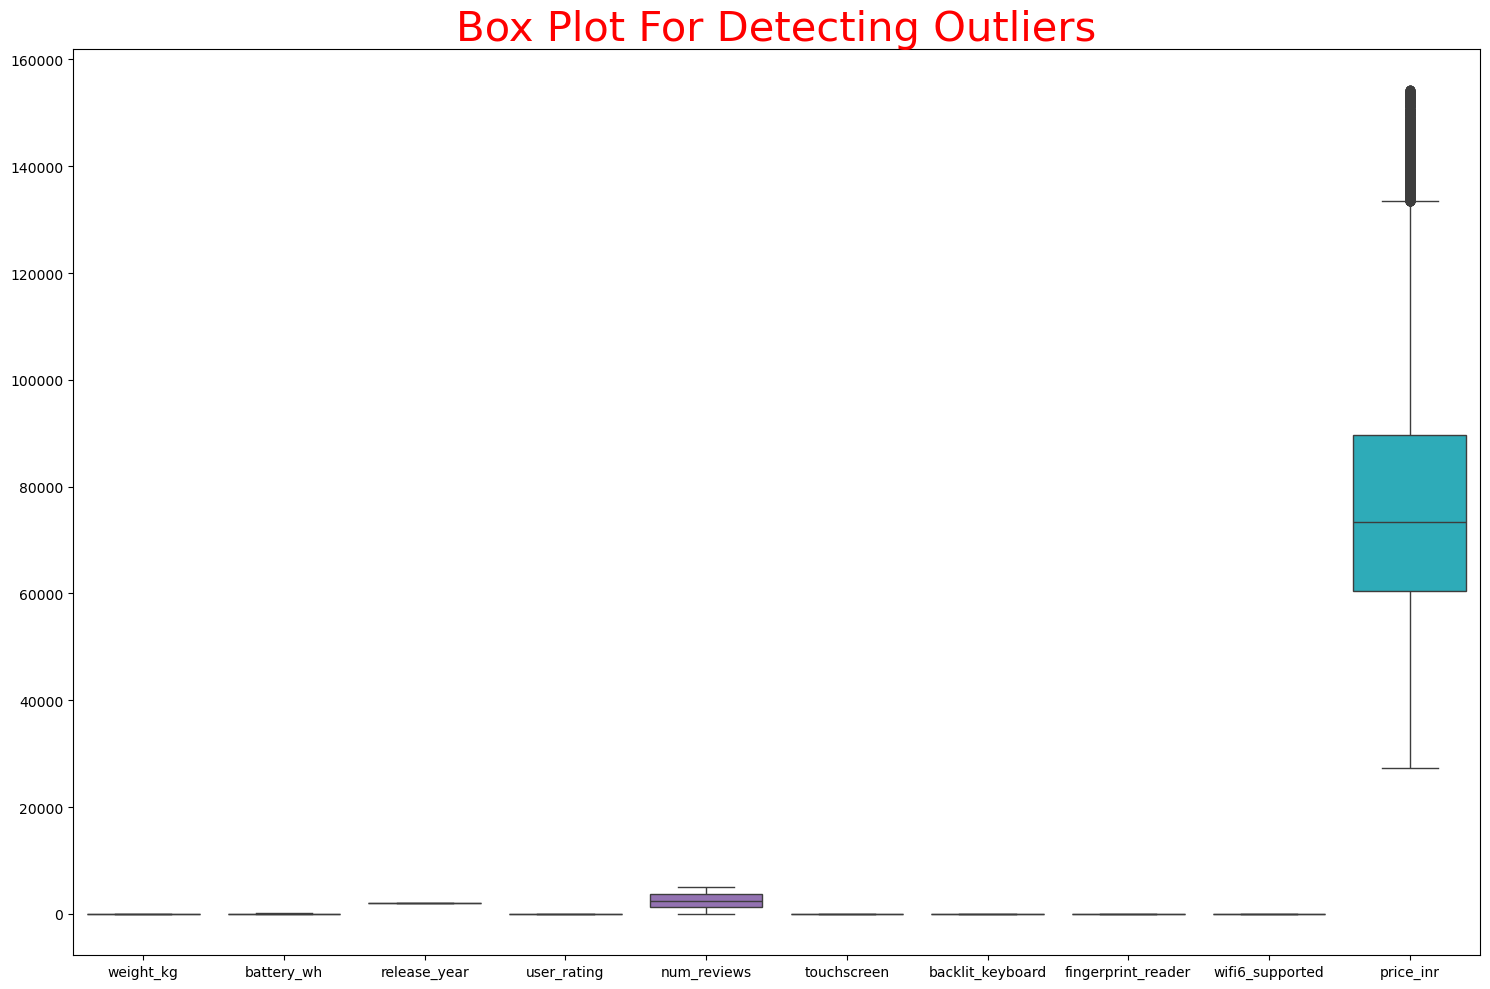

In [19]:
plt.figure(figsize=(15,10))
sns.boxplot(data=data[outlier_1])
plt.title("Box Plot For Detecting Outliers",color="red",size=30)
plt.tight_layout()
plt.show()

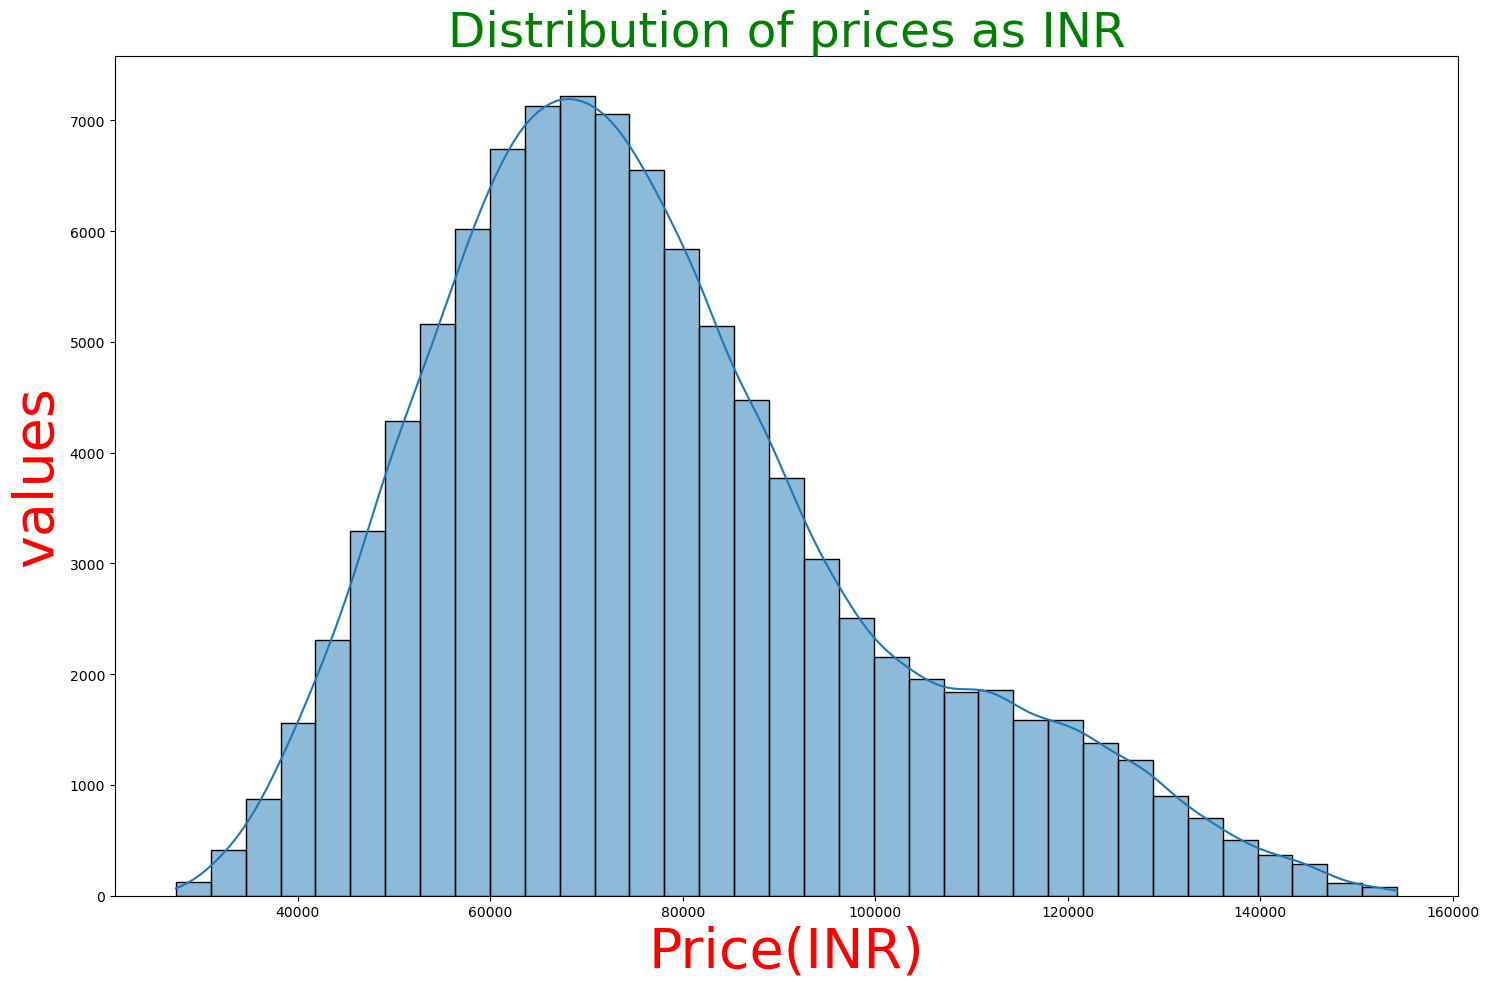

In [20]:
#relations between data through visualization
plt.figure(figsize=(15,10))
sns.histplot(data=data["price_inr"],bins=35,kde=True)
plt.title("Distribution of prices as INR",color="green",size=35)
plt.xlabel("Price(INR)",color="red",size=40)
plt.ylabel("values",color="red",size=40)
plt.tight_layout()
plt.show()

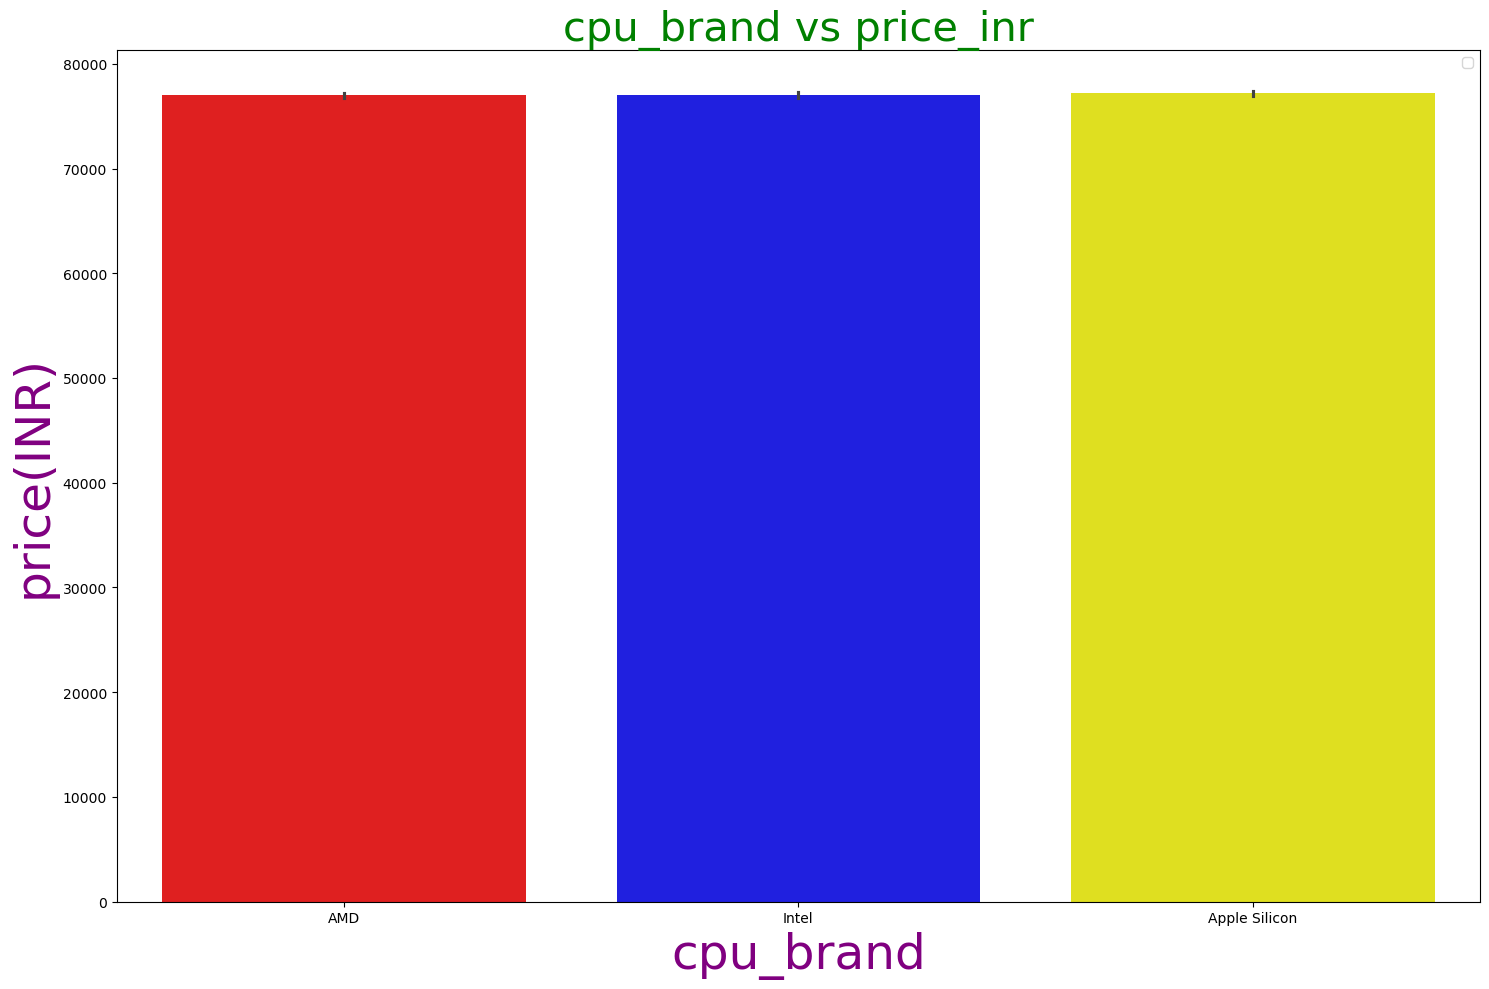

In [ ]:
plt.figure(figsize=(15,10))
colors=["red","blue","yellow"]
sns.barplot(x=data["cpu_brand"],y=data["price_inr"],palette=colors)
plt.title("cpu_brand vs price_inr",color="green",size=30)
plt.xlabel("cpu_brand",size=35,color="purple")
plt.ylabel("price(INR)",size=35,color="purple")
plt.legend()
plt.tight_layout()
plt.show()

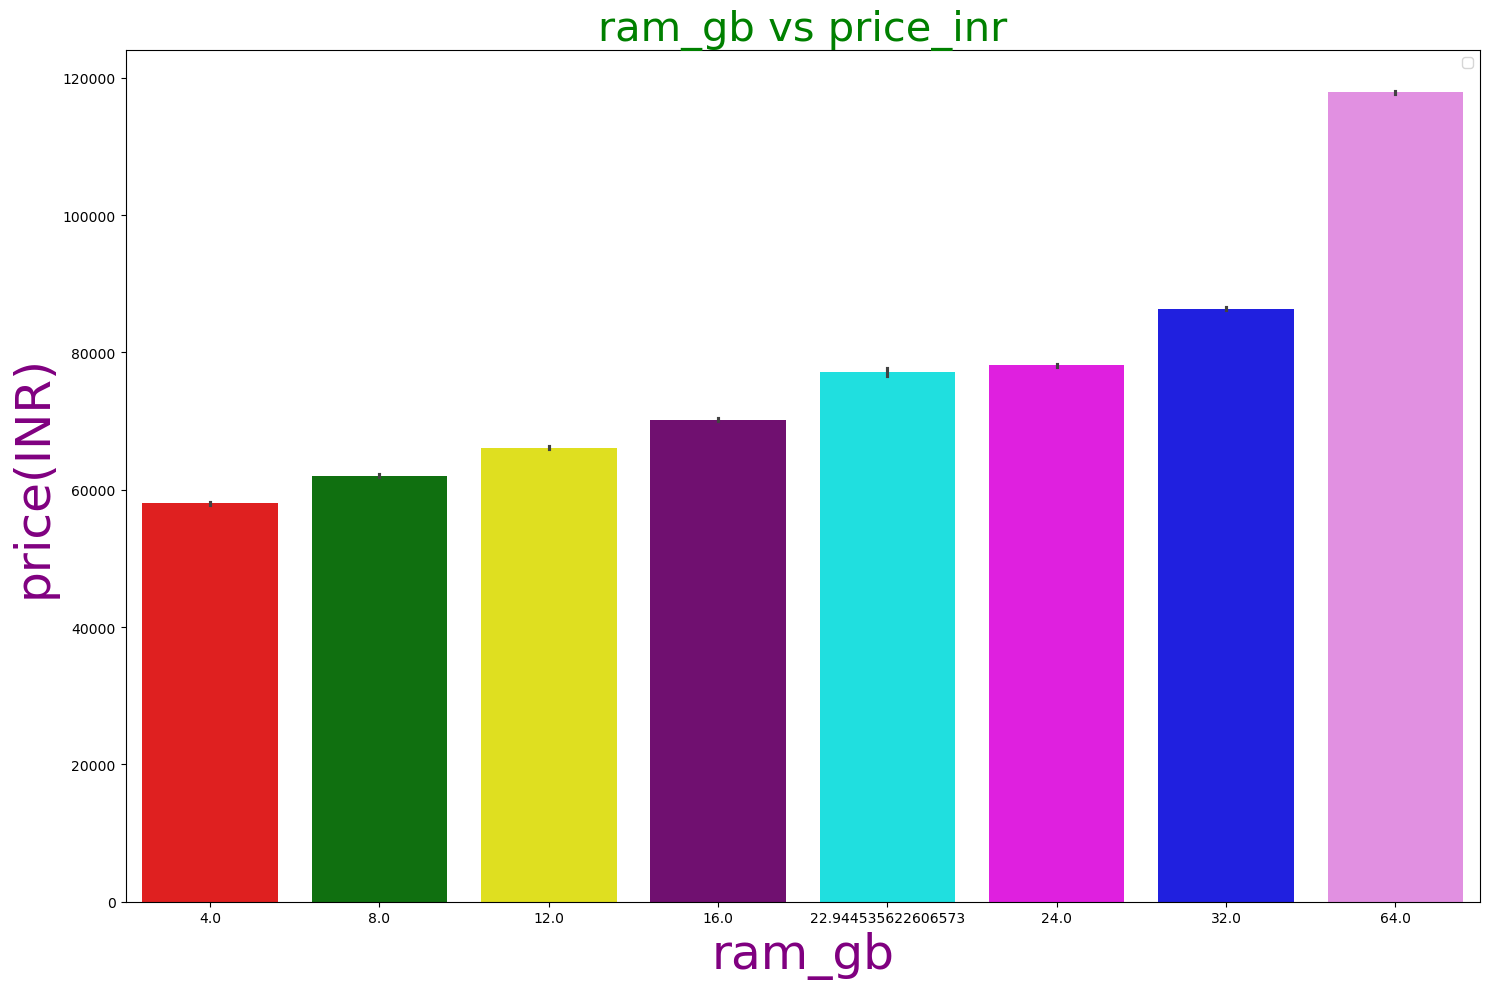

In [22]:
plt.figure(figsize=(15,10))
colors=["red","green","yellow","purple","cyan","magenta","blue","violet"]
sns.barplot(x=data["ram_gb"],y=data["price_inr"],palette=colors)
plt.title("ram_gb vs price_inr",color="green",size=30)
plt.xlabel("ram_gb",size=35,color="purple")
plt.ylabel("price(INR)",size=35,color="purple")
plt.legend()
plt.tight_layout()
plt.show()

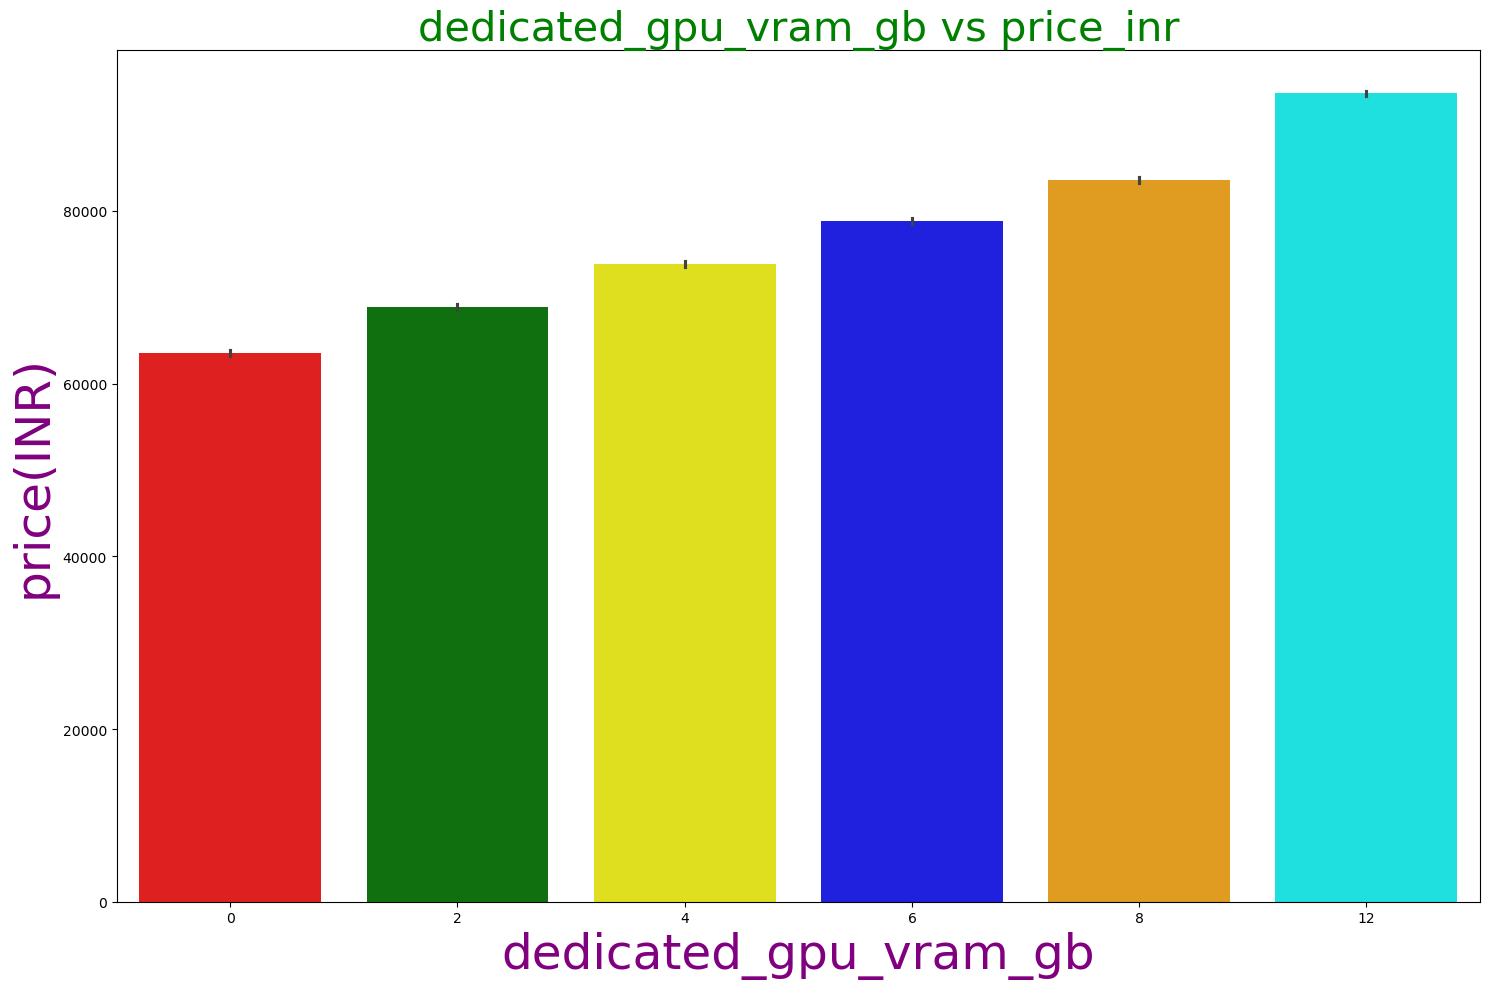

In [23]:
plt.figure(figsize=(15,10))
colors=["red","green","yellow","blue","orange","cyan"]
sns.barplot(x=data["dedicated_gpu_vram_gb"],y=data["price_inr"],palette=colors)
plt.title("dedicated_gpu_vram_gb vs price_inr",color="green",size=30)
plt.xlabel("dedicated_gpu_vram_gb",size=35,color="purple")
plt.ylabel("price(INR)",size=35,color="purple")
plt.tight_layout()
plt.show()

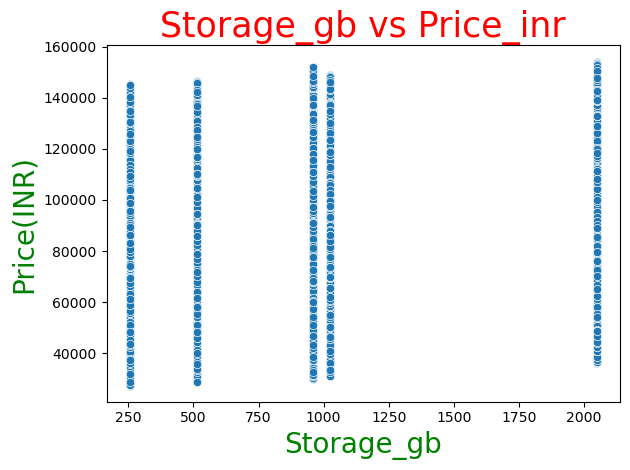

In [24]:
# plt.figure(figsize=(7,3))
sns.scatterplot(x=data["storage_gb"],y=data["price_inr"])
plt.title("Storage_gb vs Price_inr",color="red",size=25)
plt.xlabel("Storage_gb",color="green",size=20)
plt.ylabel("Price(INR)",color="green",size=20)
plt.tight_layout()
plt.show()

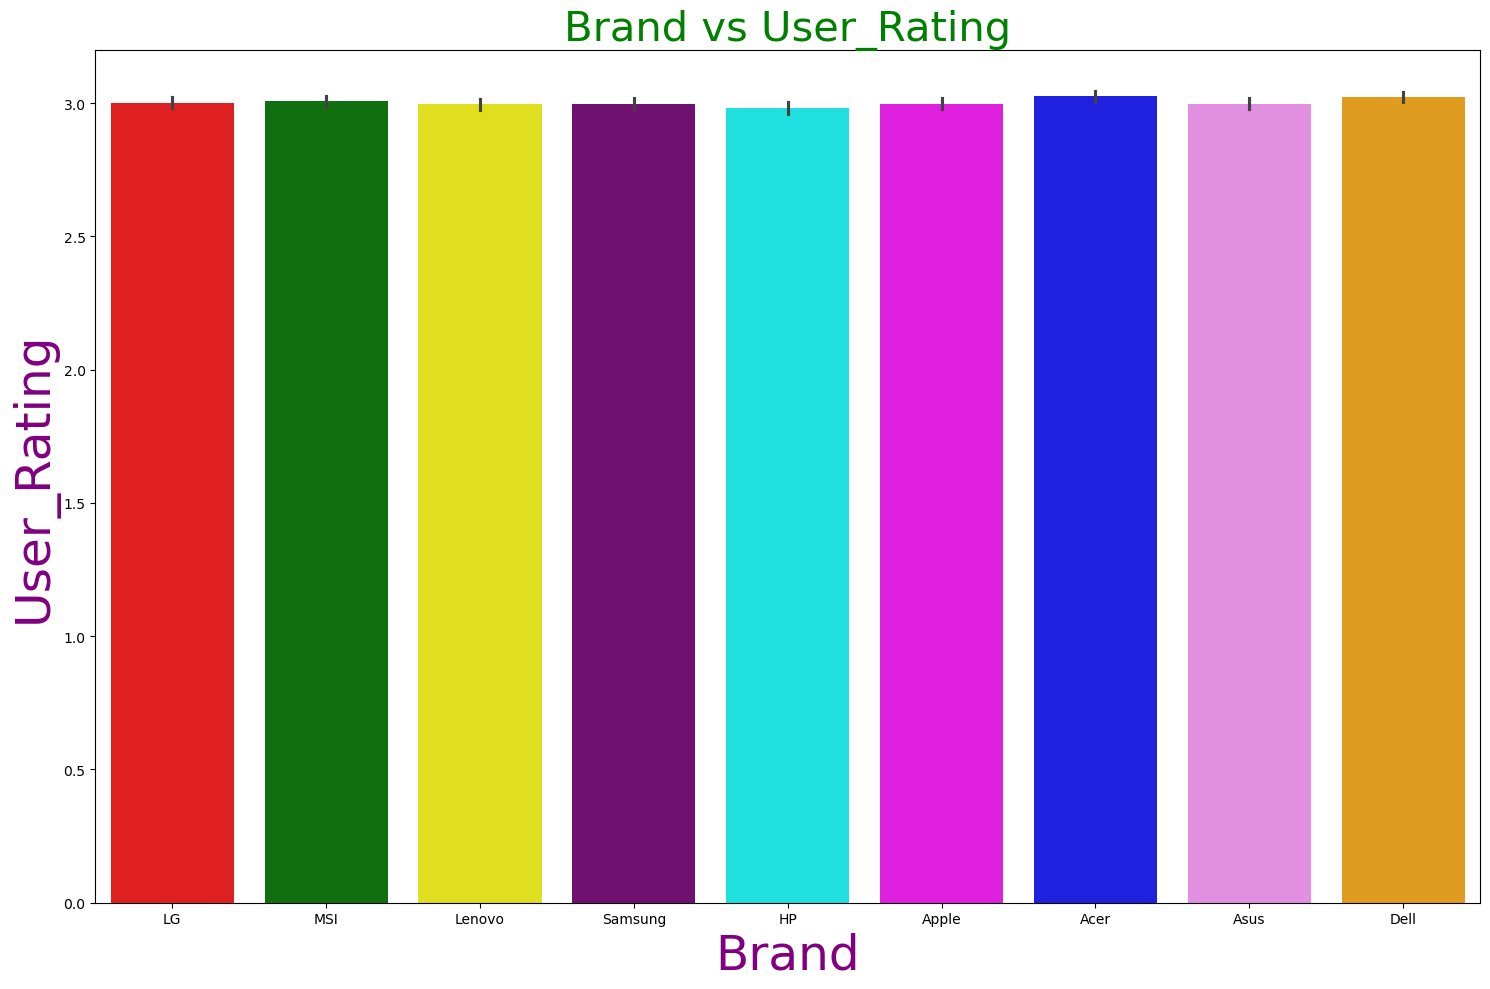

In [25]:
plt.figure(figsize=(15,10))
colors=["red","green","yellow","purple","cyan","magenta","blue","violet","orange"]
sns.barplot(x=data["brand"],y=data["user_rating"],palette=colors)
plt.title("Brand vs User_Rating",color="green",size=30)
plt.xlabel("Brand",size=35,color="purple")
plt.ylabel("User_Rating",size=35,color="purple")
plt.tight_layout()
plt.show()